# Phase 1 — Person Detection & Multi-Object Tracking

**Goal:** Use YOLOv8 for person detection and DeepSORT for persistent multi-object tracking.


In [1]:
import cv2
import numpy as np
import json
import csv
import time
import os
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm

from ultralytics import YOLO
from deep_sort_realtime.deepsort_tracker import DeepSort

# Use env var or fallback to repo-relative video for portability
INPUT_VIDEO_PATH = Path(os.environ.get('INPUT_VIDEO_PATH', '../vidp.mp4'))
OUTPUT_DIR = Path("../outputs")
OUTPUT_VIDEO_PATH   = OUTPUT_DIR / "videos"  / "phase1_tracked.mp4"
TRACKS_JSON_PATH    = OUTPUT_DIR / "analytics" / "raw_tracks.json"

OUTPUT_VIDEO_PATH.parent.mkdir(parents=True, exist_ok=True)
TRACKS_JSON_PATH.parent.mkdir(parents=True, exist_ok=True)

YOLO_MODEL       = "yolov8m.pt"
CONF_THRESHOLD   = 0.40
NMS_THRESHOLD    = 0.40
PERSON_CLASS_ID  = 0
MAX_AGE          = 30
MIN_HITS         = 3
IOU_THRESHOLD    = 0.30
MAX_COSINE_DIST  = 0.30
PROCESS_EVERY_N_FRAMES = 1
FRAME_SKIP_RATIO       = 1

print('✅ Configuration loaded.')
print(f'   Input:  {INPUT_VIDEO_PATH}')
print(f'   Output: {OUTPUT_VIDEO_PATH}')

✅ Configuration loaded.
   Input:  ..\vidp.mp4
   Output: ..\outputs\videos\phase1_tracked.mp4


In [2]:
cap = cv2.VideoCapture(str(INPUT_VIDEO_PATH))
if not cap.isOpened():
    # Try alternative common locations
    alt = Path('../assets/input_video.mp4')
    if alt.exists():
        cap = cv2.VideoCapture(str(alt))
        INPUT_VIDEO_PATH = alt
    else:
        raise FileNotFoundError(f"Cannot open video: {INPUT_VIDEO_PATH}. Place video at {INPUT_VIDEO_PATH} or set env var INPUT_VIDEO_PATH.")

FRAME_WIDTH  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
FRAME_HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS          = cap.get(cv2.CAP_PROP_FPS)
TOTAL_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
DURATION_SEC = TOTAL_FRAMES / FPS if FPS else 0

cap.release()

print(f'📹 Video Properties')
print(f'   Resolution : {FRAME_WIDTH} × {FRAME_HEIGHT}')
print(f'   FPS        : {FPS:.2f}')
print(f'   Frames     : {TOTAL_FRAMES}')
print(f'   Duration   : {DURATION_SEC:.1f}s ({DURATION_SEC/60:.1f} min)')

📹 Video Properties
   Resolution : 1920 × 1080
   FPS        : 25.00
   Frames     : 341
   Duration   : 13.6s (0.2 min)


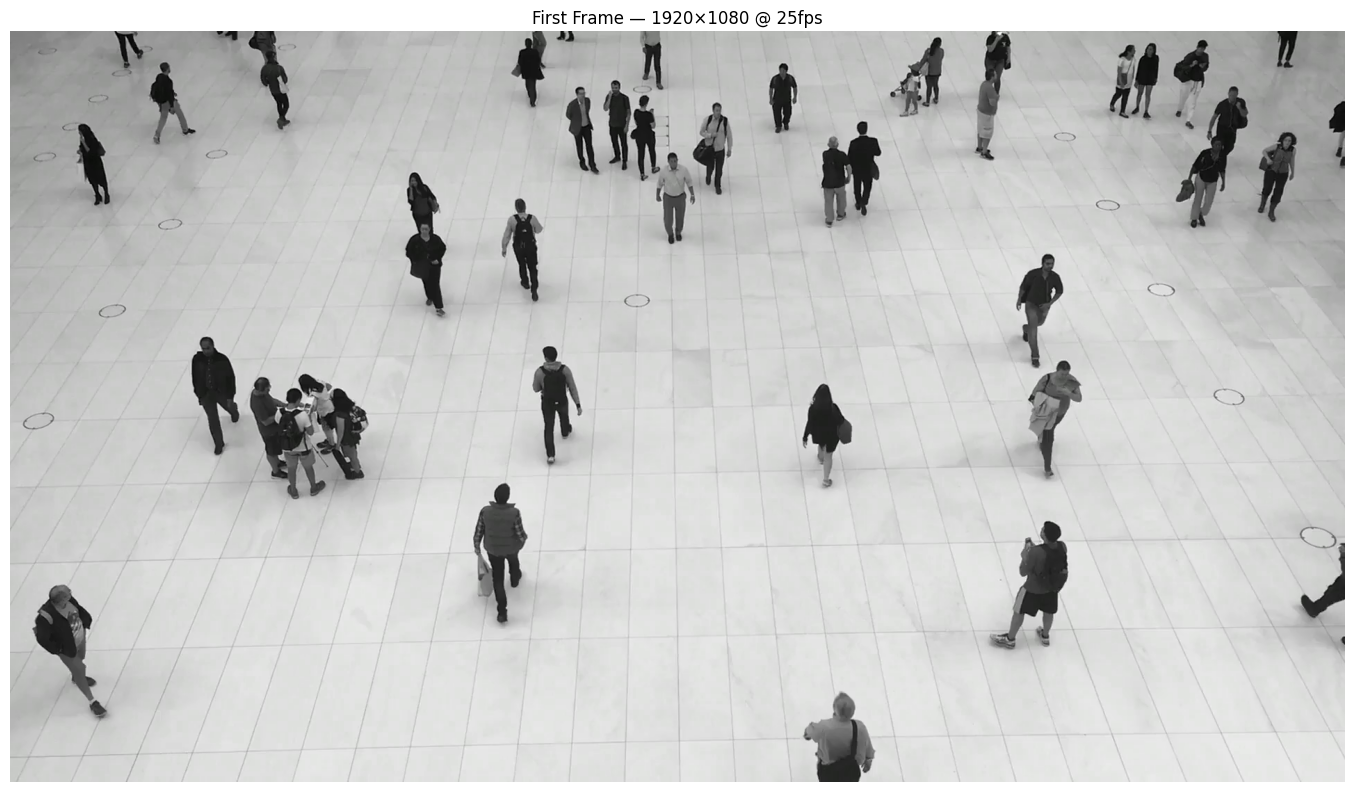

✅ First frame saved to outputs/analytics/first_frame.png
   ⚡ Use this to define zones in Phase 2!


In [3]:
import matplotlib.pyplot as plt
from IPython.display import display

cap = cv2.VideoCapture(INPUT_VIDEO_PATH)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(14, 8))
    plt.imshow(frame_rgb)
    plt.title(f'First Frame — {FRAME_WIDTH}×{FRAME_HEIGHT} @ {FPS:.0f}fps')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('../outputs/analytics/first_frame.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ First frame saved to outputs/analytics/first_frame.png')
    print('   ⚡ Use this to define zones in Phase 2!')
else:
    print('❌ Failed to read first frame')

In [4]:
print('Loading YOLOv8 model...')
if not Path(YOLO_MODEL).exists():
    raise FileNotFoundError(f'YOLO model not found: {YOLO_MODEL}. Place model file in the repo or update YOLO_MODEL variable.')
model = YOLO(YOLO_MODEL)
try:
    model.fuse()
except Exception:
    print('Warning: model.fuse() failed or is unavailable for this ultralytics version')
# Warmup if frame dims available
try:
    dummy = np.zeros((FRAME_HEIGHT, FRAME_WIDTH, 3), dtype=np.uint8)
    _ = model(dummy, verbose=False)
except Exception:
    print('YOLO warmup failed; continuing')

print(f'✅ YOLOv8 model loaded: {YOLO_MODEL}')
try:
    device = next(model.model.parameters()).device
except Exception:
    device = 'unknown'
print(f'   Device: {device}')

Loading YOLOv8 model...
YOLOv8m summary (fused): 92 layers, 25,886,080 parameters, 0 gradients, 78.9 GFLOPs
✅ YOLOv8 model loaded: yolov8m.pt
   Device: cpu


In [5]:
tracker = DeepSort(
    max_age             = MAX_AGE,
    n_init              = MIN_HITS,
    max_cosine_distance = MAX_COSINE_DIST,
    nms_max_overlap     = NMS_THRESHOLD,
    max_iou_distance    = 1.0 - IOU_THRESHOLD,
    nn_budget           = 100,
    embedder            = 'mobilenet',
    half                = False,
    bgr                 = True,
    embedder_gpu        = False
)
print('✅ DeepSORT tracker initialized.')
print(f'   max_age={MAX_AGE}, min_hits={MIN_HITS}, iou_thresh={IOU_THRESHOLD}, cosine_dist={MAX_COSINE_DIST}')

✅ DeepSORT tracker initialized.
   max_age=30, min_hits=3, iou_thresh=0.3, cosine_dist=0.3


In [6]:
def detect_persons(frame: np.ndarray, model, conf_thresh: float) -> list:
    results = model(
        frame,
        conf    = conf_thresh,
        iou     = NMS_THRESHOLD,
        classes = [PERSON_CLASS_ID],
        verbose = False
    )[0]
    
    detections = []
    for box in results.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        conf = float(box.conf[0])
        cls  = int(box.cls[0])
        detections.append([x1, y1, x2, y2, conf, cls])
    
    return detections


def detections_to_deepsort_format(detections: list) -> list:
    ds_dets = []
    for x1, y1, x2, y2, conf, cls in detections:
        w = x2 - x1
        h = y2 - y1
        if w > 5 and h > 10:
            ds_dets.append(([x1, y1, w, h], conf, 'person'))
    return ds_dets

print('✅ Detection helpers defined.')

✅ Detection helpers defined.


In [7]:
class TrackStore:
    def __init__(self, fps: float):
        self.fps = fps
        self.tracks = {}
        self.id_switches = 0
        self._lost_ids = set()
        self._active_ids = set()
    
    def update(self, frame_idx: int, active_tracks: list):
        current_ids = set()
        timestamp = frame_idx / self.fps
        
        for track in active_tracks:
            if not track.is_confirmed():
                continue
            
            tid = track.track_id
            bbox = track.to_ltrb()
            cx   = int((bbox[0] + bbox[2]) / 2)
            cy   = int((bbox[1] + bbox[3]) / 2)
            
            if tid not in self.tracks:
                self.tracks[tid] = []
            
            self.tracks[tid].append({
                'frame'     : frame_idx,
                'timestamp' : round(timestamp, 3),
                'bbox'      : [int(b) for b in bbox],
                'centroid'  : [cx, cy],
                'zone'      : None
            })
            current_ids.add(tid)
        
        disappeared = self._active_ids - current_ids
        appeared    = current_ids - self._active_ids
        
        for gone_id in disappeared:
            self._lost_ids.add(gone_id)
        
        for new_id in appeared:
            if self._lost_ids:
                self.id_switches += 1
                self._lost_ids.discard(min(self._lost_ids))
        
        self._active_ids = current_ids
    
    def total_unique_ids(self) -> int:
        return len(self.tracks)
    
    def to_dict(self) -> dict:
        return {
            'metadata': {
                'fps'              : self.fps,
                'total_unique_ids' : self.total_unique_ids(),
                'estimated_id_switches': self.id_switches
            },
            'tracks': self.tracks
        }

print('✅ TrackStore class defined.')

✅ TrackStore class defined.


In [8]:
PALETTE = [
    (255,  56,  56), (255, 157,  51), (255, 221,  51), ( 51, 255, 153),
    ( 51, 208, 255), ( 51,  80, 255), (153,  51, 255), (255,  51, 255),
    (255, 153, 204), (128, 255,   0), (  0, 255, 255), (255, 128,   0),
]

def get_color(track_id) -> tuple:
    try:
        tid = int(track_id)
    except Exception:
        tid = abs(hash(track_id))
    return PALETTE[tid % len(PALETTE)]


def draw_track(frame: np.ndarray, track, show_centroid: bool = True) -> np.ndarray:
    if not track.is_confirmed():
        return frame
    
    tid = int(track.track_id)
    color = get_color(tid)
    x1, y1, x2, y2 = map(int, track.to_ltrb())
    
    
    cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
    label    = f'ID:{tid}'
    (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
    cv2.rectangle(frame, (x1, y1 - th - 6), (x1 + tw + 4, y1), color, -1)
    cv2.putText(frame, label, (x1 + 2, y1 - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 0, 0), 2)
    
    if show_centroid:
        cx, cy = int((x1 + x2) / 2), int((y1 + y2) / 2)
        cv2.circle(frame, (cx, cy), 4, color, -1)
    
    return frame


def draw_frame_info(frame: np.ndarray, frame_idx: int, fps: float,
                    n_tracks: int) -> np.ndarray:
    ts  = frame_idx / fps
    txt = f'Frame:{frame_idx}  |  {ts:.1f}s  |  Active:{n_tracks}'
    cv2.rectangle(frame, (0, 0), (len(txt) * 9, 26), (0, 0, 0), -1)
    cv2.putText(frame, txt, (5, 18),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1)
    return frame

print('✅ Drawing utilities defined.')

✅ Drawing utilities defined.


In [9]:
cap = cv2.VideoCapture(str(INPUT_VIDEO_PATH))
if not cap.isOpened():
    raise FileNotFoundError(f'Cannot open video: {INPUT_VIDEO_PATH}')

FW  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
FH  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
FPS_VAL = cap.get(cv2.CAP_PROP_FPS) or 30.0
TOTAL   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 0

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, FPS_VAL, (FW, FH))
if not writer.isOpened():
    print('Warning: VideoWriter not opened successfully. Check codecs; attempting with avc1.')
    fourcc = cv2.VideoWriter_fourcc(*'avc1')
    writer = cv2.VideoWriter(str(OUTPUT_VIDEO_PATH), fourcc, FPS_VAL, (FW, FH))

store  = TrackStore(fps=FPS_VAL)
frame_idx = 0

start_time = time.time()

try:
    with tqdm(total=TOTAL, desc='Processing', unit='frame') as pbar:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            detections   = detect_persons(frame, model, CONF_THRESHOLD)
            ds_format    = detections_to_deepsort_format(detections)

            tracks = tracker.update_tracks(ds_format, frame=frame)
            confirmed_tracks = [t for t in tracks if t.is_confirmed()]

            store.update(frame_idx, confirmed_tracks)

            annotated = frame.copy()
            for track in confirmed_tracks:
                annotated = draw_track(annotated, track)
            annotated = draw_frame_info(annotated, frame_idx, FPS_VAL, len(confirmed_tracks))

            writer.write(annotated)
            frame_idx += 1
            pbar.update(1)
except Exception as e:
    print('ERROR during processing:', e)
finally:
    cap.release()
    writer.release()
    # Save partial tracks to disk (JSON-serializable)
    try:
        tracks_data = store.to_dict()
        with open(TRACKS_JSON_PATH, 'w') as f:
            json.dump(tracks_data, f, indent=2, default=lambda o: o.item() if hasattr(o, 'item') else (list(o) if hasattr(o, '__iter__') and not isinstance(o, (str, bytes)) else str(o)))
        print(f'✅ Saved tracks (partial): {TRACKS_JSON_PATH}')
    except Exception as e2:
        print('Failed to save tracks:', e2)

elapsed = time.time() - start_time
print(f'\n✅ Phase 1 complete in {elapsed:.1f}s ({elapsed/60:.1f} min)')
print(f'   Frames processed  : {frame_idx}')
print(f'   Total unique IDs  : {store.total_unique_ids()}')
print(f'   Est. ID switches  : {store.id_switches}')
print(f'   Output video      : {OUTPUT_VIDEO_PATH}')

Processing:   0%|          | 0/341 [00:00<?, ?frame/s]

✅ Saved tracks (partial): ..\outputs\analytics\raw_tracks.json

✅ Phase 1 complete in 319.7s (5.3 min)
   Frames processed  : 341
   Total unique IDs  : 66
   Est. ID switches  : 29
   Output video      : ..\outputs\videos\phase1_tracked.mp4


In [10]:
tracks_data = store.to_dict()

with open(TRACKS_JSON_PATH, 'w') as f:
    json.dump(tracks_data, f, indent=2)

print(f'✅ Raw tracks saved: {TRACKS_JSON_PATH}')
print(f'   Keys: {list(tracks_data.keys())}')
print(f'   Tracks: {len(tracks_data["tracks"])} unique persons')

for tid, frames in list(tracks_data['tracks'].items())[:5]:
    first_ts = frames[0]['timestamp']
    last_ts  = frames[-1]['timestamp']
    print(f'   Track {tid}: {len(frames)} frames, {first_ts:.1f}s → {last_ts:.1f}s')
print('   ...')

✅ Raw tracks saved: ..\outputs\analytics\raw_tracks.json
   Keys: ['metadata', 'tracks']
   Tracks: 66 unique persons
   Track 1: 339 frames, 0.1s → 13.6s
   Track 2: 126 frames, 0.1s → 5.1s
   Track 3: 267 frames, 0.1s → 10.7s
   Track 4: 160 frames, 0.1s → 6.4s
   Track 5: 162 frames, 0.1s → 6.5s
   ...


=== Phase 1 Summary ===
  Video duration     : 13.6s
  Total unique IDs   : 66
  Estimated switches : 29
  Avg track duration : 6.6s
  Max track duration : 13.5s
  Min track duration : 0.2s


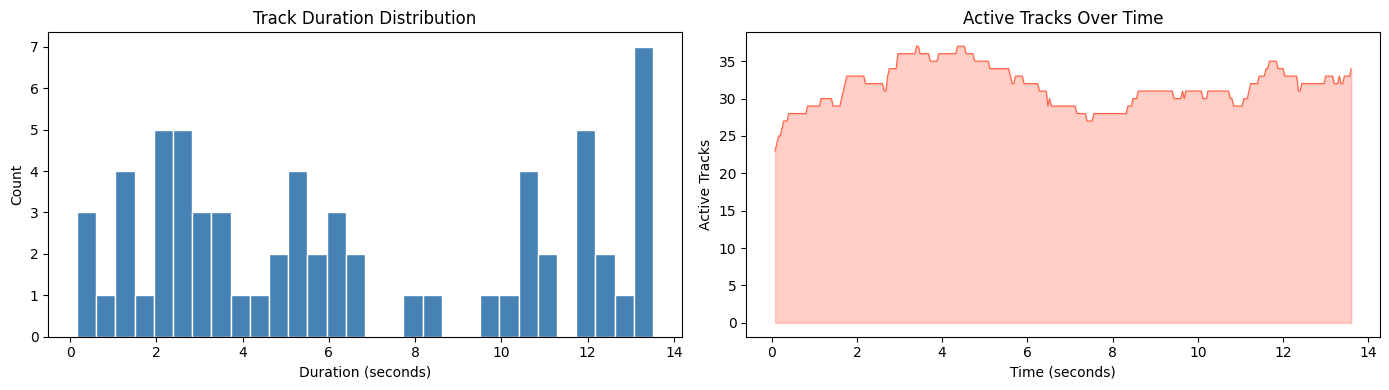

✅ Phase 1 chart saved.


In [11]:
import matplotlib.pyplot as plt

track_durations = []
for tid, frames in tracks_data['tracks'].items():
    if len(frames) > 1:
        dur = frames[-1]['timestamp'] - frames[0]['timestamp']
        track_durations.append(dur)

print('=== Phase 1 Summary ===')
print(f'  Video duration     : {frame_idx / FPS_VAL:.1f}s')
print(f'  Total unique IDs   : {store.total_unique_ids()}')
print(f'  Estimated switches : {store.id_switches}')
print(f'  Avg track duration : {np.mean(track_durations):.1f}s')
print(f'  Max track duration : {np.max(track_durations):.1f}s')
print(f'  Min track duration : {np.min(track_durations):.1f}s')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(track_durations, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Track Duration Distribution')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')

frame_counts = defaultdict(int)
for tid, frames in tracks_data['tracks'].items():
    for f in frames:
        frame_counts[f['frame']] += 1

sorted_frames = sorted(frame_counts.keys())
times  = [f / FPS_VAL for f in sorted_frames]
counts = [frame_counts[f] for f in sorted_frames]

axes[1].plot(times, counts, color='tomato', linewidth=0.8)
axes[1].fill_between(times, counts, alpha=0.3, color='tomato')
axes[1].set_title('Active Tracks Over Time')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Active Tracks')

plt.tight_layout()
plt.savefig('../outputs/analytics/phase1_track_stats.png', dpi=150)
plt.show()
print('✅ Phase 1 chart saved.')